<a href="https://colab.research.google.com/github/muhammadfisabilillah/Logistik-order-service/blob/main/tubesdataminingkelompok8fixBANGET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MOUNT DRIVE & SETUP


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Library berhasil diimport")

Library berhasil diimport


## DATA UNDERSTANDING & DATA PREPERATION


In [ ]:
import pandas as pd

# Sesuaikan dengan lokasi folder di Drive Anda
# Biasanya berada di: /content/drive/MyDrive/NAMA_FOLDER_ANDA/
file_path = '/content/drive/MyDrive/TUBES_DATAMINING_KEL8/udara-surabaya.csv'

df_raw = pd.read_csv(file_path)

print("Dataset berhasil diload")
print(f"Jumlah baris: {df_raw.shape[0]}")
print(f"Jumlah kolom: {df_raw.shape[1]}")

In [ ]:
print("5 Baris Pertama")
display(df_raw.head())

print("\n5 Baris Terakhir ")
display(df_raw.tail())

5 Baris Pertama


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,32.305882,21.482353,451.294118,28.617647,23.200000,46.529412,0.262353,0.0,3.129412,NaN,NaN
4,2022-08-05,34.079167,23.158333,478.666667,30.095833,26.433333,37.375000,0.241667,0.0,2.325000,73.764706,52.705882



5 Baris Terakhir 


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
1293,2026-02-14,42.945833,42.537500,989.208333,29.754167,18.483333,85.125000,0.447083,0.0,2.145833,112.750000,72.125000
1294,2026-02-15,44.925000,44.825000,1191.666667,34.783333,15.891667,75.208333,0.436667,0.0,2.437500,125.666667,76.458333
1295,2026-02-16,42.866667,42.762500,883.166667,38.700000,17.816667,54.291667,0.472500,0.0,1.406250,122.000000,75.375000
1296,2026-02-17,50.533333,49.562500,1169.666667,41.800000,18.625000,54.375000,0.453750,0.0,1.664583,126.916667,77.125000
1297,2026-02-18,29.491667,27.845833,725.125000,35.575000,15.437500,43.375000,0.287917,0.0,1.547917,100.916667,68.333333


In [ ]:
# kolom yg dipakai
kolom_pakai = ['date', 'pm10', 'pm2_5', 'carbon_monoxide',
               'nitrogen_dioxide', 'sulphur_dioxide', 'us_aqi']

df = df_raw[kolom_pakai].copy()
df.columns = ['date', 'pm10', 'pm2_5', 'carbon_monoxide',
              'nitrogen_dioxide', 'sulphur_dioxide', 'us_aqi']

print("Kolom berhasil diseleksi")
print(f"Kolom yang digunakan: {list(df.columns)}")
display(df.head())

Kolom berhasil diseleksi
Kolom yang digunakan: ['date', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'us_aqi']


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,us_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,32.305882,21.482353,451.294118,28.617647,23.200000,NaN
4,2022-08-05,34.079167,23.158333,478.666667,30.095833,26.433333,73.764706


In [ ]:
print("Informasi Dataset")
print(df.info())

print("\n Tipe Data Tiap Kolom ")
print(df.dtypes)

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1298 entries, 0 to 1297
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              1298 non-null   object 
 1   pm10              1295 non-null   float64
 2   pm2_5             1295 non-null   float64
 3   carbon_monoxide   1295 non-null   float64
 4   nitrogen_dioxide  1295 non-null   float64
 5   sulphur_dioxide   1295 non-null   float64
 6   us_aqi            1294 non-null   float64
dtypes: float64(6), object(1)
memory usage: 71.1+ KB
None

 Tipe Data Tiap Kolom 
date                 object
pm10                float64
pm2_5               float64
carbon_monoxide     float64
nitrogen_dioxide    float64
sulphur_dioxide     float64
us_aqi              float64
dtype: object


In [ ]:
# statistika deskriptif
print(" Statistik Deskriptif ")
display(df.describe().round(2))

 Statistik Deskriptif 


,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,us_aqi
count,1295.00,1295.00,1295.00,1295.00,1295.00,1294.00
mean,49.18,38.73,955.94,37.84,25.57,107.16
std,21.91,18.41,458.57,19.89,14.26,34.60
min,0.97,0.69,59.25,0.00,0.41,14.12
25%,32.05,24.30,599.15,22.19,16.94,78.21
50%,44.01,35.12,851.17,34.96,22.05,101.83
75%,61.64,50.49,1209.06,48.12,31.83,138.17
max,139.88,119.53,3128.83,126.01,98.27,181.00


In [ ]:
#cek missing value
print(" Jumlah Missing Value per Kolom ")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
display(missing_df)

print(f"\nTotal baris dengan minimal 1 missing value: {df.isnull().any(axis=1).sum()}")

 Jumlah Missing Value per Kolom 


,Jumlah Missing,Persentase (%)
date,0,0.00
pm10,3,0.23
pm2_5,3,0.23
carbon_monoxide,3,0.23
nitrogen_dioxide,3,0.23
sulphur_dioxide,3,0.23
us_aqi,4,0.31



Total baris dengan minimal 1 missing value: 4


In [ ]:
import pandas as pd
df_raw = pd.read_csv('/content/udara-surabaya.csv')
#cek duplikasi data
jumlah_duplikat = df_raw.duplicated().sum()
print(f"Jumlah baris duplikat: {jumlah_duplikat}")

if jumlah_duplikat > 0:
    print("Detail baris duplikat:")
    display(df_raw[df_raw.duplicated()])
else:
    print("Tidak ada duplikasi data")

Jumlah baris duplikat: 0
Tidak ada duplikasi data


In [ ]:
#hapus missing value
baris_sebelum = len(df)

df_clean = df.dropna().copy()

baris_sesudah = len(df_clean)
baris_dihapus = baris_sebelum - baris_sesudah

print(f"Baris sebelum cleaning : {baris_sebelum}")
print(f"Baris dihapus (missing): {baris_dihapus}")
print(f"Baris sesudah cleaning : {baris_sesudah}")

Baris sebelum cleaning : 1298
Baris dihapus (missing): 4
Baris sesudah cleaning : 1294


In [ ]:
#label kategori ISPU
def label_ispu(aqi):
    if aqi <= 50:
        return 'Baik'
    elif aqi <= 100:
        return 'Sedang'
    elif aqi <= 200:
        return 'Tidak Sehat'
    elif aqi <= 300:
        return 'Sangat Tidak Sehat'
    else:
        return 'Berbahaya'

df_clean['kategori_ispu'] = df_clean['us_aqi'].apply(label_ispu)

print("Kolom kategori_ispu berhasil dibuat")
print("\nDistribusi Kategori ISPU:")
print(df_clean['kategori_ispu'].value_counts())

Kolom kategori_ispu berhasil dibuat

Distribusi Kategori ISPU:
kategori_ispu
Tidak Sehat    669
Sedang         623
Baik             2
Name: count, dtype: int64


In [ ]:
# Drop kolom us_aqi karena sudah digantikan kategori_ispu
df_clean = df_clean.drop(columns=['us_aqi'])

# Reset index & preview final
df_clean = df_clean.reset_index(drop=True)

print("Dataset Final Siap Modeling")
print(f"Jumlah baris : {df_clean.shape[0]}")
print(f"Jumlah kolom : {df_clean.shape[1]}")
print(f"\nKolom        : {list(df_clean.columns)}")
display(df_clean.head(10))

Dataset Final Siap Modeling
Jumlah baris : 1294
Jumlah kolom : 7

Kolom        : ['date', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'kategori_ispu']


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,kategori_ispu
0,2022-08-05,34.079167,23.158333,478.666667,30.095833,26.433333,Sedang
1,2022-08-06,58.512500,39.816667,637.708333,34.675000,36.995833,Tidak Sehat
2,2022-08-07,43.529167,29.454167,515.208333,31.054167,31.787500,Tidak Sehat
3,2022-08-08,33.054167,22.841667,499.083333,33.141667,28.020833,Sedang
4,2022-08-09,25.358333,17.245833,403.958333,24.345833,19.787500,Sedang
5,2022-08-10,26.300000,17.820833,359.250000,20.058333,16.716667,Sedang
6,2022-08-11,25.875000,17.350000,308.041667,17.050000,15.025000,Sedang
7,2022-08-12,31.845833,21.237500,382.875000,21.991667,15.962500,Sedang
8,2022-08-13,22.445833,14.804167,517.166667,24.887500,17.145833,Sedang
9,2022-08-14,19.700000,13.108333,548.041667,28.383333,19.191667,Sedang


DOWNLOAD DATASET BERSIH

In [ ]:
from google.colab import files

# Menentukan nama file yang konsisten
file_name = 'dataset_ispu_surabaya_clean.csv'
save_path = f'/content/{file_name}'

# Menyimpan dataframe ke CSV
df_clean.to_csv(save_path, index=False)

# Mengunduh file ke komputer lokal
files.download(save_path)

print("Dataset bersih berhasil diexport")
print(f"File: {file_name}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset bersih berhasil diexport
File: dataset_ispu_surabaya_clean.csv


## MODELLING

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from imblearn.over_sampling import SMOTE

print("Library modeling berhasil diimport")

Library modeling berhasil diimport


In [ ]:
import os

# Mencari file secara otomatis di seluruh sistem file Colab
search_filename = 'dataset_ispu_surabaya_clean.csv'
found_path = None

for root, dirs, files in os.walk('/content'):
    if search_filename in files:
        found_path = os.path.join(root, search_filename)
        break

if found_path:
    print(f"File ditemukan di: {found_path}")
    # Anda bisa menggunakan found_path ini untuk menyalin
else:
    print("File tidak ditemukan. Pastikan Anda sudah mengunggah file ke sesi Colab saat ini.")

File ditemukan di: /content/drive/MyDrive/Tubes Data Mining/dataset_ispu_surabaya_clean.csv


In [ ]:
import pandas as pd

# Gunakan path yang ditemukan oleh sistem
file_path = '/content/drive/MyDrive/Tubes Data Mining/dataset_ispu_surabaya_clean.csv'

# Memuat dataset
df_raw = pd.read_csv(file_path)

# Melakukan filter sesuai keinginan Anda
df_raw = df_raw[df_raw['kategori_ispu'] != 'Baik']

print("Dataset berhasil diload")
print(f"Jumlah baris: {df_raw.shape[0]}")
print(f"Jumlah kolom: {df_raw.shape[1]}")

Dataset berhasil diload
Jumlah baris: 1292
Jumlah kolom: 7


In [ ]:
df_clean = df_raw[df_raw[ 'kategori_ispu'] != 'Baik'].copy()
kolom_fitur = ['pm10', 'pm2_5', 'carbon_monoxide',
                 'nitrogen_dioxide', 'sulphur_dioxide']

X = df_clean[kolom_fitur]
y = df_clean['kategori_ispu']

print(f"Jumlah fitur : {X.shape[1]}")
print(f"Jumlah data  : {X.shape[0]}")
print(f"\nDistribusi kelas:")
print(y.value_counts())

Jumlah fitur : 5
Jumlah data  : 1292

Distribusi kelas:
kategori_ispu
Tidak Sehat    669
Sedang         623
Name: count, dtype: int64


In [ ]:
#split data training & testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Training : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Data Testing  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.1f}%)")

Data Training : 1033 baris (80.0%)
Data Testing  : 259 baris (20.0%)


In [ ]:
!pip install imbalanced-learn -q

In [ ]:
from imblearn.over_sampling import SMOTE

print("SMOTE berhasil diimport")

SMOTE berhasil diimport


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
#train test 80:20 sebelum smote
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_1 = DecisionTreeClassifier(criterion='gini', random_state=42)
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)

akurasi_1 = accuracy_score(y_test, y_pred_1)
print("=" * 30)
print("  AKURASI 80:20 TANPA SMOTE")
print("=" * 30)
print(f"  Akurasi : {akurasi_1 * 100:.2f}%")
print(classification_report(y_test, y_pred_1))

  AKURASI 80:20 TANPA SMOTE
  Akurasi : 88.03%
              precision    recall  f1-score   support

      Sedang       0.85      0.90      0.88       123
 Tidak Sehat       0.91      0.86      0.88       136

    accuracy                           0.88       259
   macro avg       0.88      0.88      0.88       259
weighted avg       0.88      0.88      0.88       259



In [ ]:
#train test 80:20 sesudah smote
X_train, X_test_2, y_train, y_test_2 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

smote = SMOTE(random_state=42)
X_train_s, y_train_s = smote.fit_resample(X_train, y_train)

model_2 = DecisionTreeClassifier(criterion='gini', random_state=42)
model_2.fit(X_train_s, y_train_s)
y_pred_2 = model_2.predict(X_test_2)

akurasi_2 = accuracy_score(y_test_2, y_pred_2)
print("=" * 30)
print("  AKURASI 80:20 DENGAN SMOTE")
print("=" * 30)
print(f"  Akurasi : {akurasi_2 * 100:.2f}%")
print(classification_report(y_test_2, y_pred_2))

  AKURASI 80:20 DENGAN SMOTE
  Akurasi : 89.58%
              precision    recall  f1-score   support

      Sedang       0.89      0.89      0.89       123
 Tidak Sehat       0.90      0.90      0.90       136

    accuracy                           0.90       259
   macro avg       0.90      0.90      0.90       259
weighted avg       0.90      0.90      0.90       259



In [ ]:
print(f"Training sebelum SMOTE : {len(y_train)}")
print(y_train.value_counts())

print(f"\nTraining sesudah SMOTE : {len(y_train_s)}")
print(pd.Series(y_train_s).value_counts())


Training sebelum SMOTE : 1033
kategori_ispu
Tidak Sehat    533
Sedang         500
Name: count, dtype: int64

Training sesudah SMOTE : 1066
kategori_ispu
Sedang         533
Tidak Sehat    533
Name: count, dtype: int64


In [ ]:
#train test 70:30 sebelum smote
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model_3 = DecisionTreeClassifier(criterion='gini', random_state=42)
model_3.fit(X_train, y_train)
y_pred_3 = model_3.predict(X_test)

akurasi_3 = accuracy_score(y_test, y_pred_3)
print("=" * 30)
print("  AKURASI 70:30 TANPA SMOTE")
print("=" * 30)
print(f"  Akurasi : {akurasi_3 * 100:.2f}%")
print(classification_report(y_test, y_pred_3))

  AKURASI 70:30 TANPA SMOTE
  Akurasi : 87.63%
              precision    recall  f1-score   support

      Sedang       0.86      0.89      0.87       186
 Tidak Sehat       0.89      0.87      0.88       202

    accuracy                           0.88       388
   macro avg       0.88      0.88      0.88       388
weighted avg       0.88      0.88      0.88       388



In [ ]:
#train test 70:30 sesudah smote
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

smote = SMOTE(random_state=42)
X_train_s, y_train_s = smote.fit_resample(X_train, y_train)

model_4 = DecisionTreeClassifier(criterion='gini', random_state=42)
model_4.fit(X_train_s, y_train_s)
y_pred_4 = model_4.predict(X_test)

akurasi_4 = accuracy_score(y_test, y_pred_4)
print("=" * 30)
print("  AKURASI 70:30 DENGAN SMOTE")
print("=" * 30)
print(f"  Akurasi : {akurasi_4 * 100:.2f}%")
print(classification_report(y_test, y_pred_4))

  AKURASI 70:30 DENGAN SMOTE
  Akurasi : 87.89%
              precision    recall  f1-score   support

      Sedang       0.87      0.88      0.87       186
 Tidak Sehat       0.89      0.88      0.88       202

    accuracy                           0.88       388
   macro avg       0.88      0.88      0.88       388
weighted avg       0.88      0.88      0.88       388



In [ ]:
print(f"Training sebelum SMOTE : {len(y_train)}")
print(y_train.value_counts())

print(f"\nTraining sesudah SMOTE : {len(y_train_s)}")
print(pd.Series(y_train_s).value_counts())

Training sebelum SMOTE : 904
kategori_ispu
Tidak Sehat    467
Sedang         437
Name: count, dtype: int64

Training sesudah SMOTE : 934
kategori_ispu
Tidak Sehat    467
Sedang         467
Name: count, dtype: int64


In [ ]:
#train test 90:10 sebelum smote
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

model_5 = DecisionTreeClassifier(criterion='gini', random_state=42)
model_5.fit(X_train, y_train)
y_pred_5 = model_5.predict(X_test)

akurasi_5 = accuracy_score(y_test, y_pred_5)
print("=" * 30)
print("  AKURASI 90:10 TANPA SMOTE")
print("=" * 30)
print(f"  Akurasi : {akurasi_5 * 100:.2f}%")
print(classification_report(y_test, y_pred_5))

  AKURASI 90:10 TANPA SMOTE
  Akurasi : 96.15%
              precision    recall  f1-score   support

      Sedang       0.93      0.98      0.96        57
 Tidak Sehat       0.99      0.95      0.97        73

    accuracy                           0.96       130
   macro avg       0.96      0.96      0.96       130
weighted avg       0.96      0.96      0.96       130



In [ ]:
#train test 90:10 sesudah smote
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

smote = SMOTE(random_state=42)
X_train_s, y_train_s = smote.fit_resample(X_train, y_train)

model_6 = DecisionTreeClassifier(criterion='gini', random_state=42)
model_6.fit(X_train_s, y_train_s)
y_pred_6 = model_6.predict(X_test)

akurasi_6 = accuracy_score(y_test, y_pred_6)
print("=" * 30)
print("  AKURASI 90:10 DENGAN SMOTE")
print("=" * 30)
print(f"  Akurasi : {akurasi_6 * 100:.2f}%")
print(classification_report(y_test, y_pred_6))

  AKURASI 90:10 DENGAN SMOTE
  Akurasi : 90.77%
              precision    recall  f1-score   support

      Sedang       0.89      0.89      0.89        57
 Tidak Sehat       0.92      0.92      0.92        73

    accuracy                           0.91       130
   macro avg       0.91      0.91      0.91       130
weighted avg       0.91      0.91      0.91       130



In [ ]:
print(f"Training sebelum SMOTE : {len(y_train)}")
print(y_train.value_counts())

print(f"\nTraining sesudah SMOTE : {len(y_train_s)}")
print(pd.Series(y_train_s).value_counts())

Training sebelum SMOTE : 1162
kategori_ispu
Tidak Sehat    596
Sedang         566
Name: count, dtype: int64

Training sesudah SMOTE : 1192
kategori_ispu
Sedang         596
Tidak Sehat    596
Name: count, dtype: int64


In [ ]:
#bikin model decision three
model_dt = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

model_dt.fit(X_train, y_train)

print("Model Decision Tree berhasil dibangun")
print(f"Kedalaman pohon : {model_dt.get_depth()}")
print(f"Jumlah leaf     : {model_dt.get_n_leaves()}")

Model Decision Tree berhasil dibangun
Kedalaman pohon : 16
Jumlah leaf     : 87


In [ ]:
#prediksi data testing
y_pred = model_dt.predict(X_test)

print("Prediksi selesai")
print(f"\nContoh 10 prediksi pertama:")
hasil = pd.DataFrame({'Aktual': y_test.values[:10], 'Prediksi': y_pred[:10]})
display(hasil)

Prediksi selesai

Contoh 10 prediksi pertama:


,Aktual,Prediksi
0,Sedang,Sedang
1,Tidak Sehat,Tidak Sehat
2,Tidak Sehat,Tidak Sehat
3,Tidak Sehat,Tidak Sehat
4,Sedang,Sedang
5,Tidak Sehat,Tidak Sehat
6,Tidak Sehat,Tidak Sehat
7,Sedang,Sedang
8,Sedang,Sedang
9,Sedang,Sedang


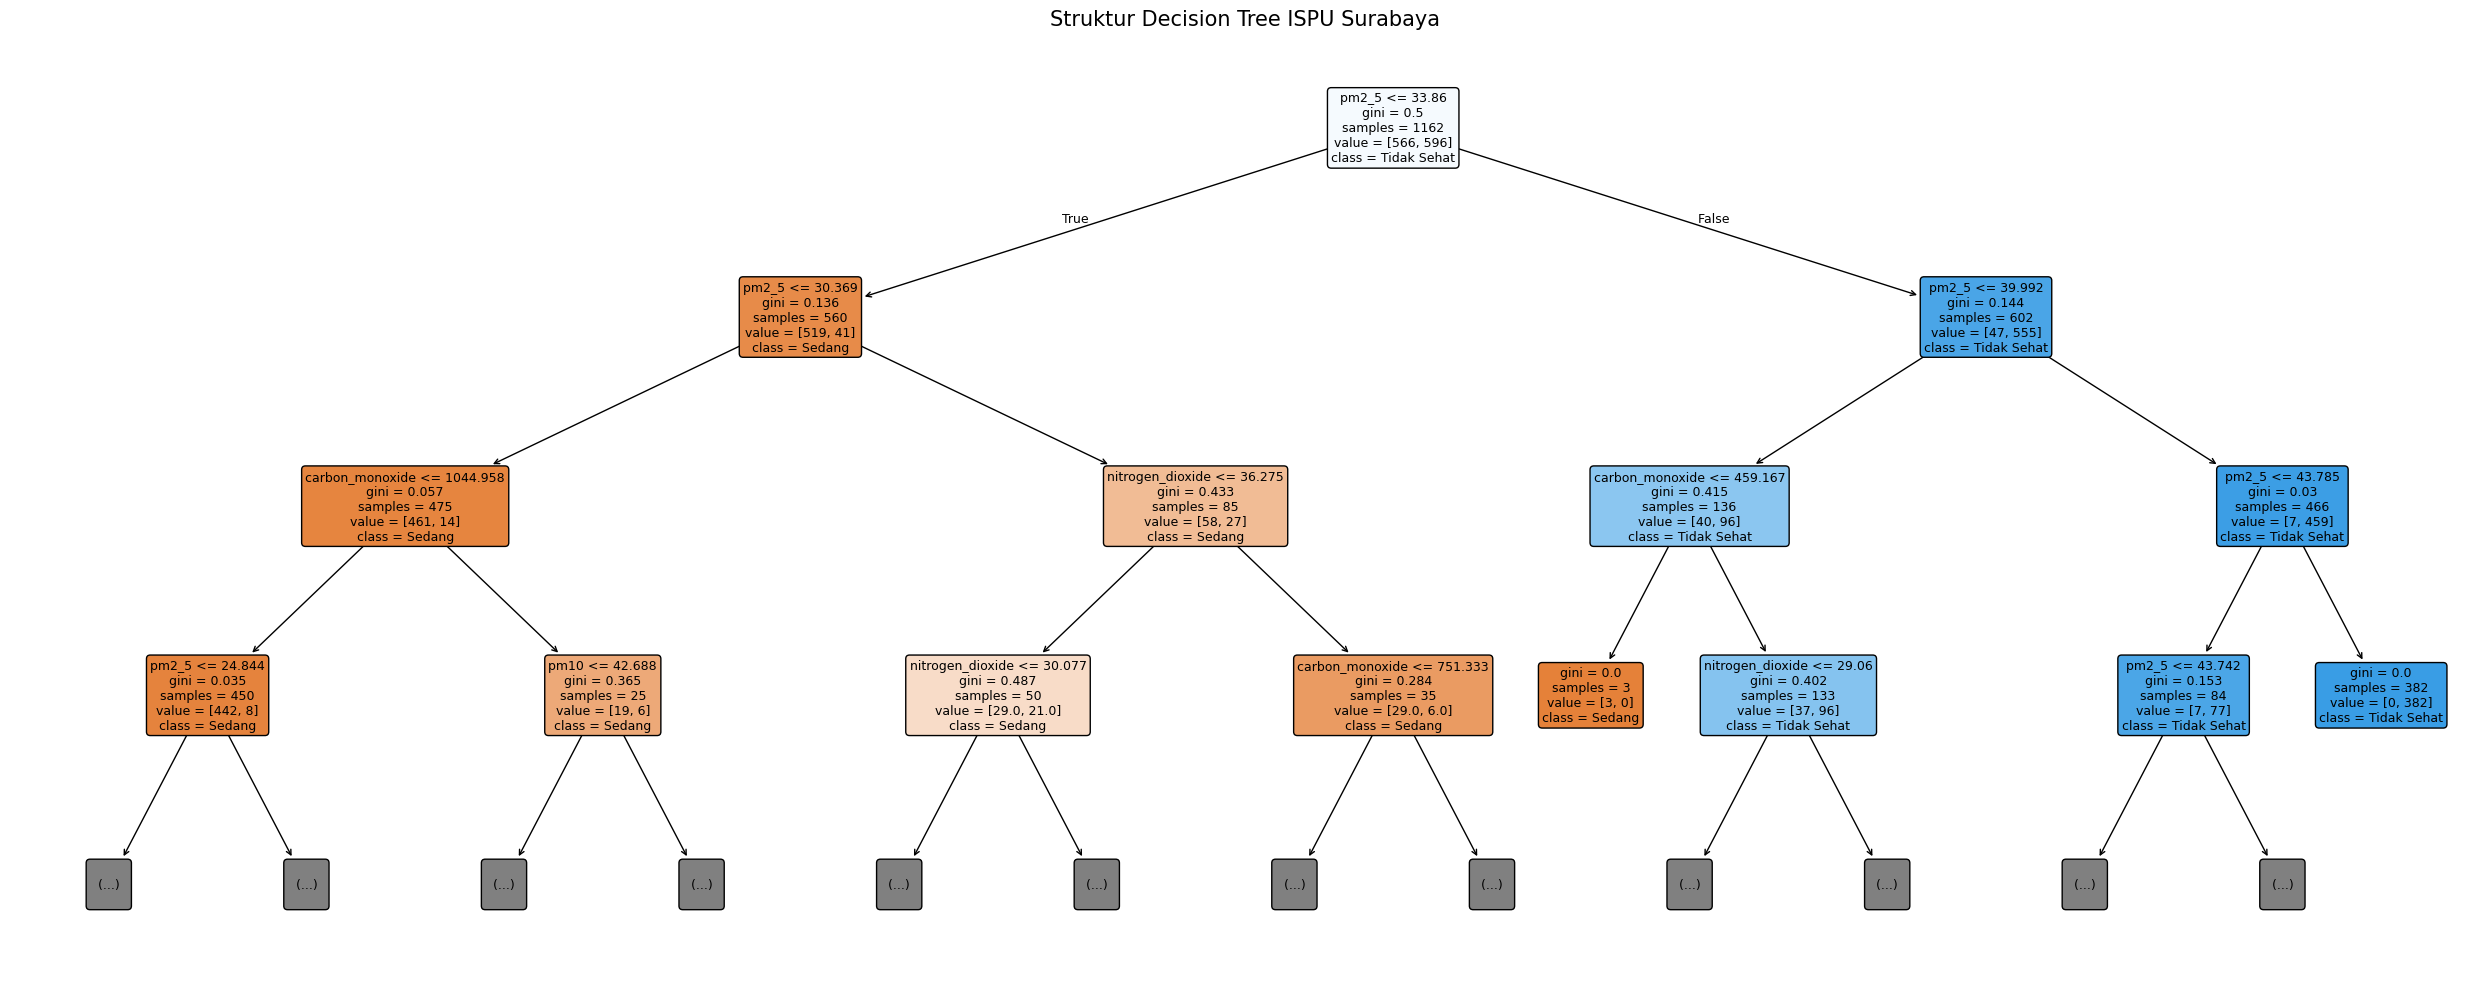

 Gambar decision_tree.png tersimpan


In [ ]:
#visualisasi decision tree

plt.figure(figsize=(25, 10))
plot_tree(
    model_dt,
    feature_names=kolom_fitur,
    class_names=model_dt.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)
plt.title('Struktur Decision Tree ISPU Surabaya', fontsize=15)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gambar decision_tree.png tersimpan")

In [ ]:
#aturan decision tree
rules = export_text(model_dt, feature_names=kolom_fitur, max_depth=4)
print("\nAturan Keputusan Decision Tree")
print(rules)


Aturan Keputusan Decision Tree
|--- pm2_5 <= 33.86
|   |--- pm2_5 <= 30.37
|   |   |--- carbon_monoxide <= 1044.96
|   |   |   |--- pm2_5 <= 24.84
|   |   |   |   |--- class: Sedang
|   |   |   |--- pm2_5 >  24.84
|   |   |   |   |--- pm2_5 <= 24.96
|   |   |   |   |   |--- class: Tidak Sehat
|   |   |   |   |--- pm2_5 >  24.96
|   |   |   |   |   |--- truncated branch of depth 7
|   |   |--- carbon_monoxide >  1044.96
|   |   |   |--- pm10 <= 42.69
|   |   |   |   |--- nitrogen_dioxide <= 47.30
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- nitrogen_dioxide >  47.30
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- pm10 >  42.69
|   |   |   |   |--- class: Tidak Sehat
|   |--- pm2_5 >  30.37
|   |   |--- nitrogen_dioxide <= 36.28
|   |   |   |--- nitrogen_dioxide <= 30.08
|   |   |   |   |--- nitrogen_dioxide <= 16.26
|   |   |   |   |   |--- class: Sedang
|   |   |   |   |--- nitrogen_dioxide >  16.26
|   |   |   |   |   |--- truncated 

Atribut Paling Berpengaruh 


,Fitur,Importance
0,pm2_5,0.8184
1,nitrogen_dioxide,0.0768
2,carbon_monoxide,0.0371
3,pm10,0.0362
4,sulphur_dioxide,0.0314


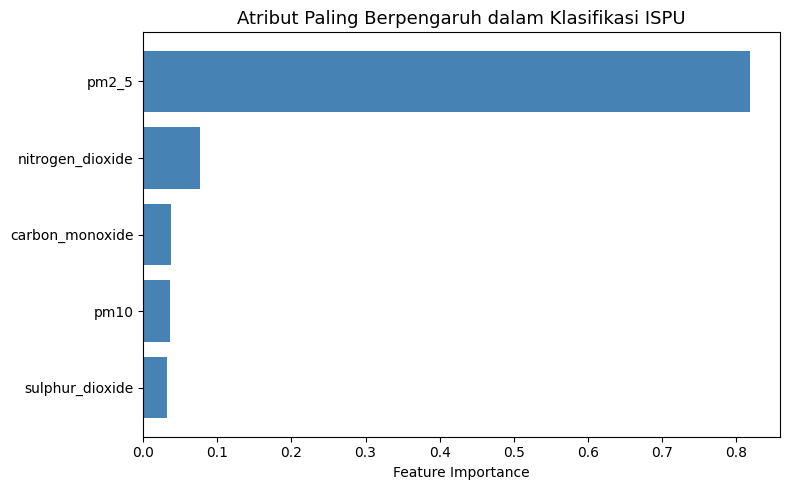

Gambar feature_importance.png tersimpan


In [ ]:
#features improtance (paling berpengaruh)
importance_df = pd.DataFrame({
    'Fitur': kolom_fitur,
    'Importance': model_dt.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Atribut Paling Berpengaruh ")
display(importance_df.round(4))

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Fitur'], importance_df['Importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Atribut Paling Berpengaruh dalam Klasifikasi ISPU', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gambar feature_importance.png tersimpan")

##K-MEANS SEBAGAI UNSUPERVISED

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Fitur untuk clustering
kolom_cluster = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide']
X_cluster = df_clean[kolom_cluster].copy()

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Data siap untuk clustering")
print(f"Jumlah data : {X_scaled.shape[0]}")
print(f"Jumlah fitur: {X_scaled.shape[1]}")

Data siap untuk clustering
Jumlah data : 1292
Jumlah fitur: 5


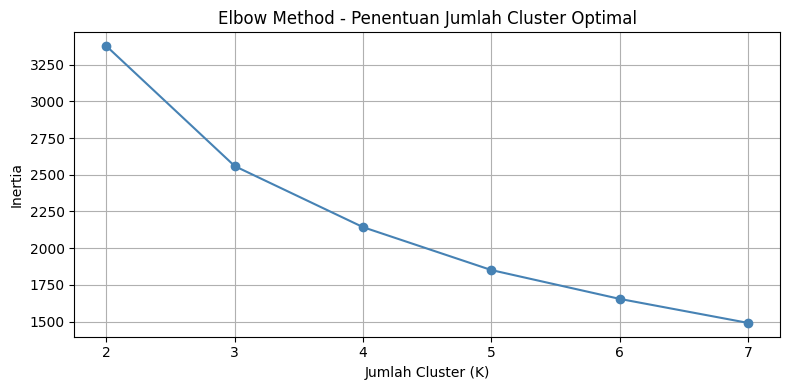

In [ ]:
inertia = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='steelblue')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Penentuan Jumlah Cluster Optimal')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

print("K-Means selesai dijalankan")
print(f"Jumlah cluster : 3")
print(f"\nDistribusi cluster:")
print(df_clean['cluster'].value_counts().sort_index())

K-Means selesai dijalankan
Jumlah cluster : 3

Distribusi cluster:
cluster
0    592
1    208
2    492
Name: count, dtype: int64


In [ ]:
sil_score = silhouette_score(X_scaled, df_clean['cluster'])

print("=" * 40)
print("     EVALUASI K-MEANS CLUSTERING")
print("=" * 40)
print(f"  Jumlah Cluster (K) : 3")
print(f"  Silhouette Score   : {sil_score:.4f}")
print("=" * 40)

if sil_score >= 0.5:
    print("  Interpretasi : Cluster terbentuk BAIK")
elif sil_score >= 0.25:
    print("  Interpretasi : Cluster terbentuk CUKUP BAIK")
else:
    print("  Interpretasi : Cluster kurang optimal")

     EVALUASI K-MEANS CLUSTERING
  Jumlah Cluster (K) : 3
  Silhouette Score   : 0.3371
  Interpretasi : Cluster terbentuk CUKUP BAIK


In [ ]:
cluster_summary = df_clean.groupby('cluster')[kolom_cluster].mean().round(2)
print("Rata-rata nilai polutan per cluster:")
display(cluster_summary)

Rata-rata nilai polutan per cluster:


,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide
cluster,,,,,
0,32.30,24.32,611.35,23.64,19.60
1,86.20,65.32,1594.99,66.66,45.49
2,53.98,44.97,1103.50,42.83,24.39


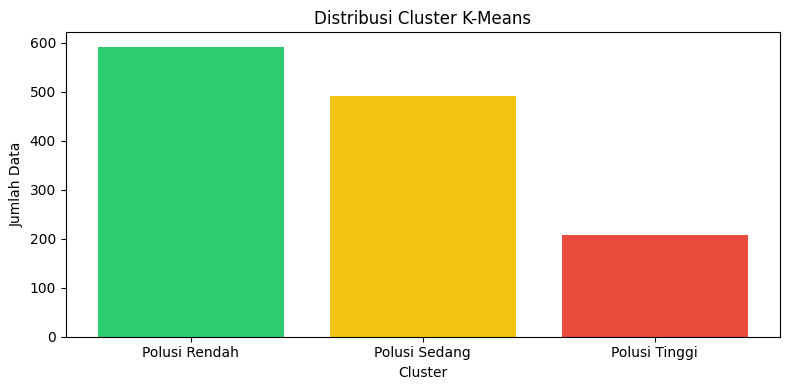

cluster_label
Polusi Rendah    592
Polusi Sedang    492
Polusi Tinggi    208
Name: count, dtype: int64


In [ ]:
cluster_label = {0: 'Polusi Rendah', 2: 'Polusi Sedang', 1: 'Polusi Tinggi'}
df_clean['cluster_label'] = df_clean['cluster'].map(cluster_label)

plt.figure(figsize=(8, 4))
counts = df_clean['cluster_label'].value_counts()
colors = ['#2ecc71', '#f1c40f', '#e74c3c']
plt.bar(counts.index, counts.values, color=colors)
plt.title('Distribusi Cluster K-Means')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.tight_layout()
plt.show()

print(df_clean['cluster_label'].value_counts())

## EVALUASI

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from google.colab import files

print("Library berhasil diimport")

Library berhasil diimport


In [ ]:
#evaluasi akurasi
print("=" * 45)
print("   PERBANDINGAN AKURASI SEMUA SKENARIO")
print("=" * 45)
print(f"  1. 80:20 Tanpa SMOTE  : {akurasi_1 * 100:.2f}%")
print(f"  2. 80:20 Dengan SMOTE : {akurasi_2 * 100:.2f}%")
print(f"  3. 70:30 Tanpa SMOTE  : {akurasi_3 * 100:.2f}%")
print(f"  4. 70:30 Dengan SMOTE : {akurasi_4 * 100:.2f}%")
print(f"  5. 90:10 Tanpa SMOTE  : {akurasi_5 * 100:.2f}%")
print(f"  6. 90:10 Dengan SMOTE : {akurasi_6 * 100:.2f}%")
print("=" * 45)
print(f"  Skenario Terbaik : 80:20 Dengan SMOTE")
print(f"  Akurasi Terbaik  : {akurasi_2 * 100:.2f}%")
print("=" * 45)

   PERBANDINGAN AKURASI SEMUA SKENARIO
  1. 80:20 Tanpa SMOTE  : 88.03%
  2. 80:20 Dengan SMOTE : 89.58%
  3. 70:30 Tanpa SMOTE  : 87.63%
  4. 70:30 Dengan SMOTE : 87.89%
  5. 90:10 Tanpa SMOTE  : 96.15%
  6. 90:10 Dengan SMOTE : 90.77%
  Skenario Terbaik : 80:20 Dengan SMOTE
  Akurasi Terbaik  : 89.58%


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_2))


Classification Report:
              precision    recall  f1-score   support

      Sedang       0.89      0.89      0.89       123
 Tidak Sehat       0.90      0.90      0.90       136

    accuracy                           0.90       259
   macro avg       0.90      0.90      0.90       259
weighted avg       0.90      0.90      0.90       259



In [ ]:
# precision, recall, F1-Score per Kelas
report = classification_report(y_test_2, y_pred_2, output_dict=True)
report_df = pd.DataFrame(report).transpose()

kelas_only = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])

print("Precision, Recall, F1-Score per Kelas")
display(kelas_only[['precision', 'recall', 'f1-score', 'support']].round(4))

Precision, Recall, F1-Score per Kelas


,precision,recall,f1-score,support
Sedang,0.8871,0.8943,0.8907,123.0
Tidak Sehat,0.9037,0.8971,0.9004,136.0


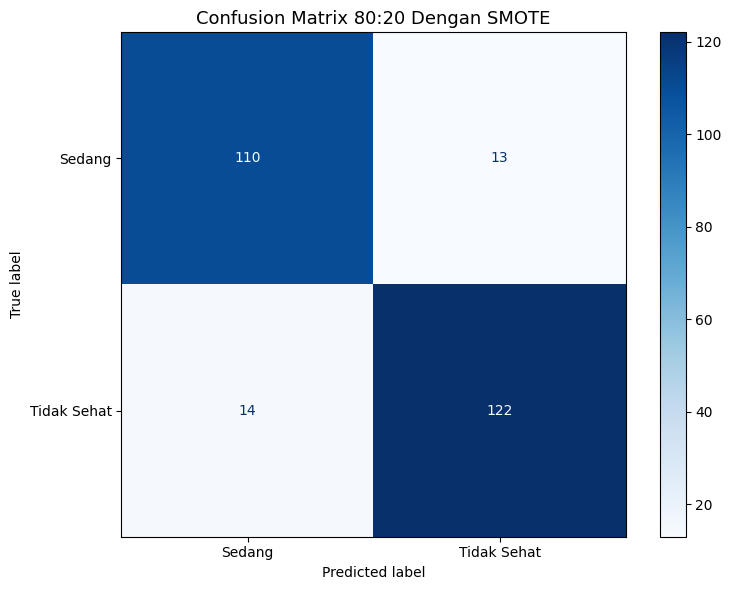

confusion_matrix.png tersimpan


In [ ]:
#confussion matrix
cm = confusion_matrix(y_test_2, y_pred_2, labels=model_2.classes_)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_2.classes_)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix 80:20 Dengan SMOTE', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("confusion_matrix.png tersimpan")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

kelas_only[['precision', 'recall']].plot(kind='bar', ax=ax, rot=0)
ax.set_title('Precision and Recall per Class')
ax.set_ylabel('Score')
ax.set_xlabel('Class')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('precision_recall.png', dpi=150, bbox_inches='tight')
plt.close(fig)

files.download('confusion_matrix.png')
files.download('precision_recall.png')

print("Semua file evaluasi berhasil didownload")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Semua file evaluasi berhasil didownload




## EVALUASI K-MEANS

In [ ]:
sil_score_final = silhouette_score(X_scaled, df_clean['cluster'])

print("=" * 30)
print("     EVALUASI K-MEANS CLUSTERING")
print("=" * 30)
print(f"  Jumlah Cluster (K) : 3")
print(f"  Jumlah Data        : {len(df_clean)}")
print(f"  Silhouette Score   : {sil_score_final:.4f}")

if sil_score_final >= 0.5:
    print("  Interpretasi : Cluster terbentuk BAIK")
elif sil_score_final >= 0.25:
    print("  Interpretasi : Cluster terbentuk CUKUP BAIK")
else:
    print("  Interpretasi : Cluster kurang optimal")


In [ ]:
#distribusi ISPU per Cluster
cross_tab = pd.crosstab(df_clean['cluster_label'], df_clean['kategori_ispu'])
display(cross_tab)


kategori_ispu,Sedang,Tidak Sehat
cluster_label,,
Polusi Rendah,508,84
Polusi Sedang,113,379
Polusi Tinggi,2,206


In [ ]:
#karakteristik tiap cluster
cluster_eval = df_clean.groupby('cluster_label')[kolom_cluster].mean().round(2)
display(cluster_eval)

,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide
cluster_label,,,,,
Polusi Rendah,32.30,24.32,611.35,23.64,19.60
Polusi Sedang,53.98,44.97,1103.50,42.83,24.39
Polusi Tinggi,86.20,65.32,1594.99,66.66,45.49


 Perbandingan Tiga Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

print("\n=== TANPA SMOTE ===")
for name, model in models.items():

    if name == "KNN":
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"{name:15s} | Accuracy: {acc:.4f}")

In [ ]:
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

models_smote = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

print("\n=== DENGAN SMOTE ===")
for name, model in models_smote.items():

    if name == "KNN":
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train_sm)
        X_test_s = scaler.transform(X_test)

        model.fit(X_train_s, y_train_sm)
        y_pred = model.predict(X_test_s)

    else:
        model.fit(X_train_sm, y_train_sm)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"{name:15s} | Accuracy: {acc:.4f}")

## DASHBOARD ISPU

In [ ]:
import joblib

joblib.dump(model_dt, 'model_ispu_dt.pkl')

In [ ]:
!pip install streamlit -q

import os
import urllib.request
from google.colab import output

# Setup direktori dan copy files dari Drive ke lokal Colab
src_dir = "/content/drive/MyDrive/TUBES_DATAMINING_KEL8"
files = ["app.py", "model_ispu_dt.pkl", "dataset_ispu_surabaya_clean.csv"]

for file in files:
    src_path = os.path.join(src_dir, file)
    if os.path.exists(src_path):
        !cp {src_path} /content/
    else:
        print(f"Peringatan: {file} tidak ditemukan di Drive.")

%cd /content/

# Generate tunnel link menggunakan internal proxy Colab
port = 8501
print("\n" + "="*50)
print(f"Link Dashboard Streamlit: {output.eval_js(f'google.colab.kernel.proxyPort({port})')}")
print("="*50 + "\n")

# Jalankan server Streamlit dengan konfigurasi headless
!streamlit run app.py --server.port 8501 --server.enableCORS=false --server.enableXsrfProtection=false --server.headless=true

/content

Link Dashboard Streamlit: https://8501-m-s-kkb-ass1b1-3quyl6xrs98d-b.asia-southeast1-1.prod.colab.dev



2026-06-24 02:27:07.189 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.142.251.131:8501

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
2026-06-24 02:27:16.561 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-06-24 02:27:16.699 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_containe

In [ ]:
!pip install session-info
import session_info
session_info.show()